### Example 4 for the usage of Rela²x.
### See README.md for more information.

- ¹H, ¹³C and ¹⁴N nuclei.

- Dipole-dipole coupling between all of the spins, CSA interactions on the ¹³C and ¹⁴N nuclei, and quadrupolar interaction on the ¹⁴N.

- Ranks $l = 2$ for all interactions.

Import Rela²x.

In [1]:
from rela2x import *

Define the spin system.

In [2]:
spin_system = ['1H', '13C', '14N']

Define the incoherent interactions.

In [3]:
dd_couplings = [[0, 1, 1],
                [0, 0, 1],
                [0, 0, 0]]
sh_interactions = [0, 1, 1]
q_interactions = [0, 0, 1]

intrs = {'CSA': ('1L', sh_interactions, [2]),
         'Q':   ('1Q', q_interactions, [2]),
         'DD':  ('2', dd_couplings, [2])}

Compute the relaxation superoperator in the direct product basis of spherical tensor operators and create a RelaxationSuperoperator object.

Use the second version of basis sorting.

**Note:** This can take a couple of minutes due to the large size of the system and the number of different cross terms present.

In [4]:
R = R_object_in_prodop_basis(spin_system, intrs, sorting='v2')


Computing R for interaction pairs...
CSA2 * CSA2
CSA2 * CSA3
CSA3 * CSA2
CSA3 * CSA3
CSA2 * Q3
CSA3 * Q3
CSA2 * DD12
CSA2 * DD13
CSA2 * DD23
CSA3 * DD12
CSA3 * DD13
CSA3 * DD23
Q3 * CSA2
Q3 * CSA3
Q3 * Q3
Q3 * DD12
Q3 * DD13
Q3 * DD23
DD12 * CSA2
DD12 * CSA3
DD13 * CSA2
DD13 * CSA3
DD23 * CSA2
DD23 * CSA3
DD12 * Q3
DD13 * Q3
DD23 * Q3
DD12 * DD12
DD12 * DD13
DD12 * DD23
DD13 * DD12
DD13 * DD13
DD13 * DD23
DD23 * DD12
DD23 * DD13
DD23 * DD23
R computed.

Changing basis...
Basis changed.

Final clean-ups...
Done.


Visualize $R$.

The block-diagonal structure where each block corresponds to different coherence order is clearly visible.

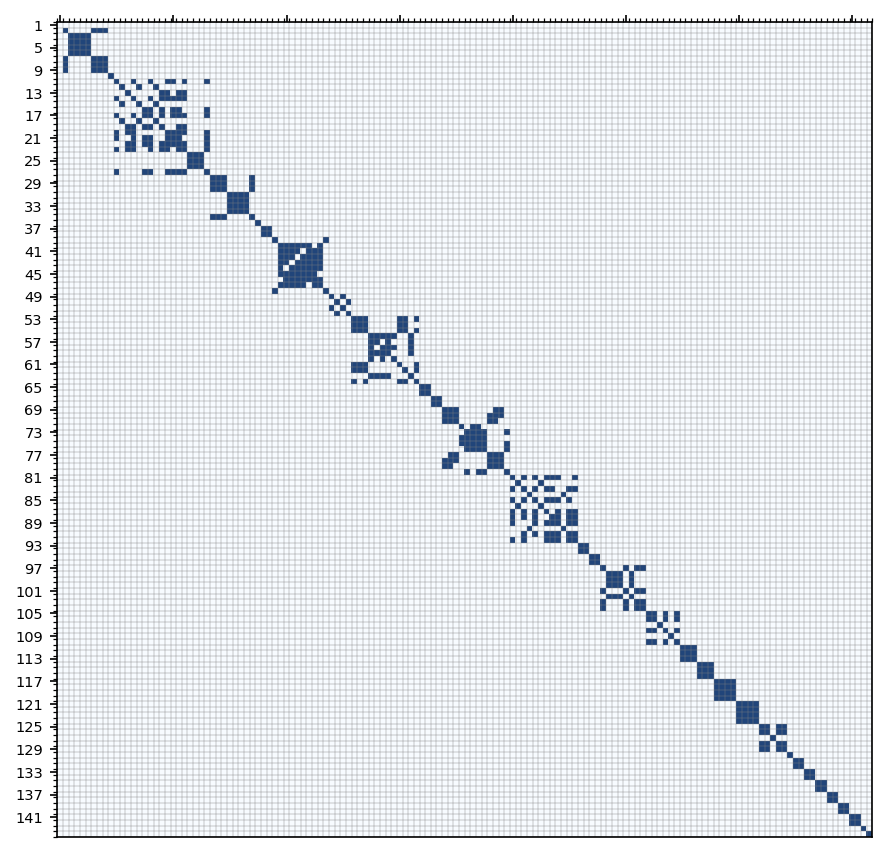

In [5]:
R.visualize()

Check the auto-relaxation rate of $\hat T_{1-1}^{(1)}$, and the cross-relaxation rate between operators $\hat T_{10}^{(1)}$ and $\hat T_{10}^{(1)} \hat T_{10}^{(2)}$

In [6]:
rate1 = R.rate('110')
rate2 = R.rate('110', '110*210*310')

display(rate1)
display(rate2)

J^{DD12}_{(2, 0)}(Abs(\omega_{1H}))/8 + J^{DD12}_{(2, 0)}(Abs(\omega_{13C} - \omega_{1H}))/24 + J^{DD12}_{(2, 0)}(Abs(\omega_{13C} + \omega_{1H}))/4 + J^{DD13}_{(2, 0)}(Abs(\omega_{1H}))/3 + J^{DD13}_{(2, 0)}(Abs(\omega_{14N} - \omega_{1H}))/9 + 2*J^{DD13}_{(2, 0)}(Abs(\omega_{14N} + \omega_{1H}))/3

J^{DD13, DD12}_{(2, 0)}(Abs(\omega_{1H}))

Study the population block only.

In [7]:
R.filter('t', 0)

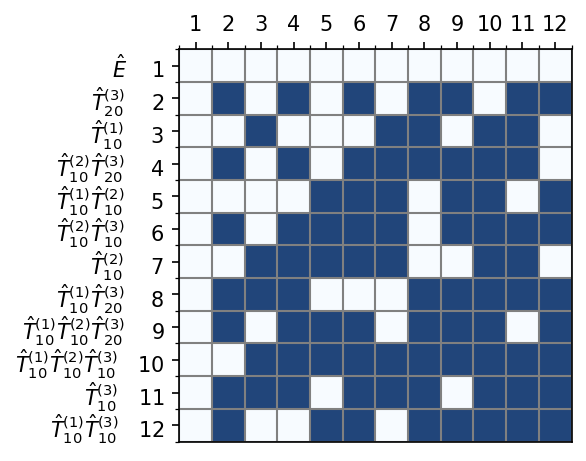

In [8]:
R.visualize(basis_symbols=R.basis_symbols)

Compute the equations of motion in the population block and save in LaTeX format.

(Remove the comment if you want to save the file)

In [9]:
# Compute the equations of motion
eoms = equations_of_motion(R.op, R.basis_symbols)
display(eoms)
# equations_of_motion_to_latex(eoms, '3-spin_test')

Eq(Matrix([
[                                                 Derivative(\langle \hat{E}\rangle(t), t)],
[                                      Derivative(\langle \hat{T}_{20}^{(3)}\rangle(t), t)],
[                                      Derivative(\langle \hat{T}_{10}^{(1)}\rangle(t), t)],
[                   Derivative(\langle \hat{T}_{10}^{(2)}*\hat{T}_{20}^{(3)}\rangle(t), t)],
[                   Derivative(\langle \hat{T}_{10}^{(1)}*\hat{T}_{10}^{(2)}\rangle(t), t)],
[                   Derivative(\langle \hat{T}_{10}^{(2)}*\hat{T}_{10}^{(3)}\rangle(t), t)],
[                                      Derivative(\langle \hat{T}_{10}^{(2)}\rangle(t), t)],
[                   Derivative(\langle \hat{T}_{10}^{(1)}*\hat{T}_{20}^{(3)}\rangle(t), t)],
[Derivative(\langle \hat{T}_{10}^{(1)}*\hat{T}_{10}^{(2)}*\hat{T}_{20}^{(3)}\rangle(t), t)],
[Derivative(\langle \hat{T}_{10}^{(1)}*\hat{T}_{10}^{(2)}*\hat{T}_{10}^{(3)}\rangle(t), t)],
[                                      Derivative(\langle 